In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# CARGAR DATASET MNIST
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)


Etiqueta de la imagen: 6


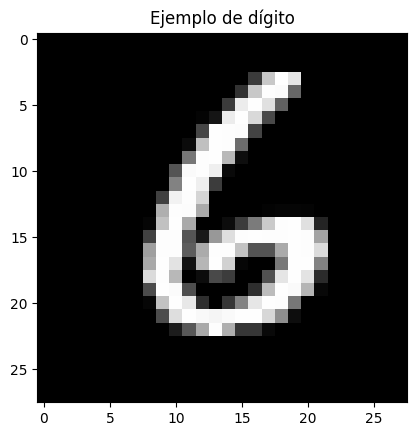

In [ ]:
# MOSTRAR UNA IMAGEN
imagen = X[6000].reshape(28,28)
etiqueta = y[6000]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.title("Ejemplo de dígito")
plt.show()


In [ ]:
# DIVISIÓN DE DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=5
)


===== SVM =====
Accuracy: 0.9135
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1389
           1       0.95      0.97      0.96      1593
           2       0.91      0.89      0.90      1409
           3       0.90      0.89      0.89      1407
           4       0.91      0.94      0.92      1348
           5       0.88      0.86      0.87      1266
           6       0.94      0.95      0.95      1380
           7       0.93      0.92      0.93      1494
           8       0.87      0.85      0.86      1333
           9       0.89      0.89      0.89      1381

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



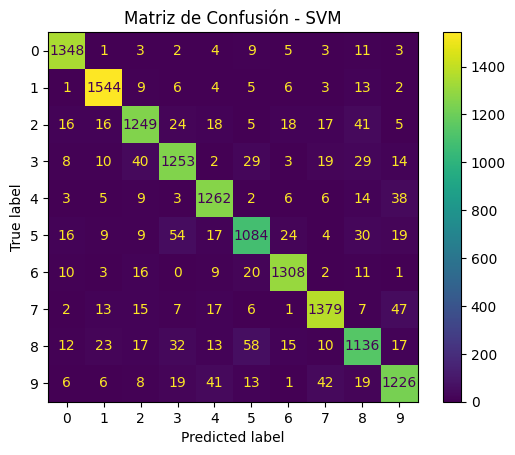

In [ ]:
# SVM
svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\n===== SVM =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

cfn_mat = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cfn_mat)
disp.plot()
plt.title("Matriz de Confusión - SVM")
plt.show()

In [11]:
# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\n===== KNN =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))




===== KNN =====
Accuracy: 0.9747142857142858
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1389
           1       0.96      1.00      0.98      1593
           2       0.98      0.97      0.97      1409
           3       0.97      0.97      0.97      1407
           4       0.98      0.97      0.97      1348
           5       0.97      0.97      0.97      1266
           6       0.98      0.99      0.98      1380
           7       0.98      0.98      0.98      1494
           8       0.99      0.94      0.97      1333
           9       0.96      0.97      0.97      1381

    accuracy                           0.97     14000
   macro avg       0.98      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [12]:
# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=50, random_state=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


===== RANDOM FOREST =====
Accuracy: 0.9680714285714286
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1389
           1       0.98      0.98      0.98      1593
           2       0.95      0.97      0.96      1409
           3       0.96      0.95      0.96      1407
           4       0.97      0.98      0.98      1348
           5       0.97      0.96      0.96      1266
           6       0.98      0.98      0.98      1380
           7       0.97      0.96      0.97      1494
           8       0.95      0.95      0.95      1333
           9       0.96      0.95      0.96      1381

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [ ]:
# GRADIENT BOOSTING
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("\n===== GRADIENT BOOSTING =====")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))



===== GRADIENT BOOSTING =====
Accuracy: 0.928
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1389
           1       0.96      0.98      0.97      1593
           2       0.93      0.92      0.93      1409
           3       0.91      0.89      0.90      1407
           4       0.91      0.94      0.93      1348
           5       0.91      0.89      0.90      1266
           6       0.95      0.94      0.94      1380
           7       0.95      0.92      0.94      1494
           8       0.90      0.90      0.90      1333
           9       0.89      0.92      0.90      1381

    accuracy                           0.93     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.93      0.93      0.93     14000



In [13]:
# COMPARACIÓN FINAL
print("\n===== COMPARACIÓN FINAL =====")
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))


===== COMPARACIÓN FINAL =====
SVM: 0.9135
KNN: 0.9747142857142858
Random Forest: 0.9680714285714286
Gradient Boosting: 0.928
